<link rel="stylesheet" href="notebooks/styles.css">

<div class="title-wrap">
  <h1 class="title-main">Spatial Data Science Approaches to Wildfire Severity Modeling</h1>
  <hr class="title-rule">
  <h2 class="title-sub">A GIS‑Driven, Tree‑Based Machine Learning Analysis of California Wildfire</h2>
</div>

## Module 4: *Variable Selection*
##### Version Number: 4.0
---
### Contents  
> 1. *Water Demand*
> 2. *Water Supply*
> 3. *Water Supply Indexes*
> 4. *Fire Danger Indicators*
> 5. *Social Variables*
> 6. *Temporal and Geographic Varaibles*
> 7. *Export File*
---
### Notes
- This module visualizes key variables to assess their relationships with wildfire severity categories. Based on the `Categorical` target, we explore how different weather features interact and correlate with fire risk.
---
### Inputs
- `engineered_samples.csv` engineered and cleaned samples data with weather, fire, and grid data.
---
### Outputs 
- `X`,`y`,`details` - Split training data filtered from 2018 to 2024
- `pal_x`, `pal_y`, `pal_details` - Split training data from 2025 for case study
---
### User Defined Dependencies

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

# Function to print a grid of kde plots in consistent format, adjusts columns and rows accordingly
from src.plot_utils import grid_kde

# Function to print a custom format correlation heatmap
from src.plot_utils import correlation_map

# Function to print simple bar charts side by side
from src.plot_utils import bar_group

In [2]:
def plot_all(df,target,title):
    grid_kde(df)
    bar_group(df)
    correlation_map(pd.concat([df,target],axis=1),title)
    

---
### Third Party Dependencies

In [3]:
# Core data tools
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

# Set consistent plotting style
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

---

### Loading Data

In [4]:
samples = pd.read_csv('../data/processed/engineered_samples.csv')

---

## Split dataset temporarily for variable analysis

In [5]:
# Columns to drop for feature interaction analysis
text_columns = ['Sample_ID', 'Date', 'grid_id',
       'geometry', 'fire_count', 'total_fire_damage','acres','area_in_cali','maximum_x', 'minimum_y',
       'maximum_y', 'minimum_x','centroid_northing','centroid_easting',
       'dominant_province_description','dominant_section_description', 'Season','Target']

numerical_data = samples.drop(columns=text_columns)
detail_data = samples[text_columns] # spatial data used for modeling and mapping
target = samples['Target']

## Scale numerical columns for easier side by side comparisons

In [6]:
scaler = MinMaxScaler()

# Scale main dataset
X_scaled = scaler.fit_transform(numerical_data)
X = pd.DataFrame(X_scaled, columns=numerical_data.columns, index=numerical_data.index)

In [ ]:
# Add Target back to main dataset for correlation examination
X['Target'] = target

## DIrect Water Demand Indicators

In [8]:
water_demand = [
    "Actual Evapotranspiration",
    "Solar Radiation",
    "Daily Minimum Air Temperature",
    "Daily Maximum Air Temperature",
    "Vapor Pressure Deficit",
    "Wind Speed",
    "Target"
]

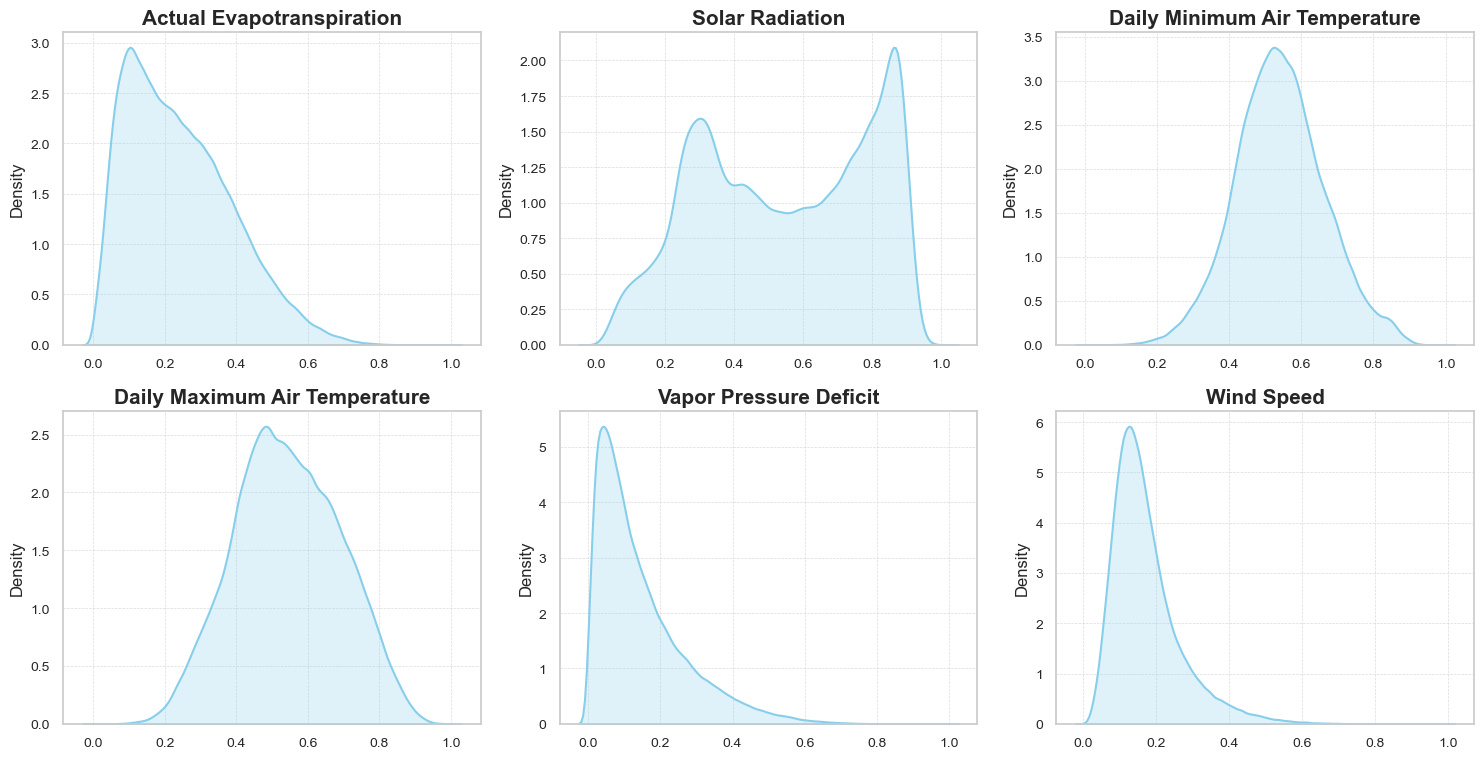

In [9]:
grid_kde(X[water_demand].drop(columns='Target'))

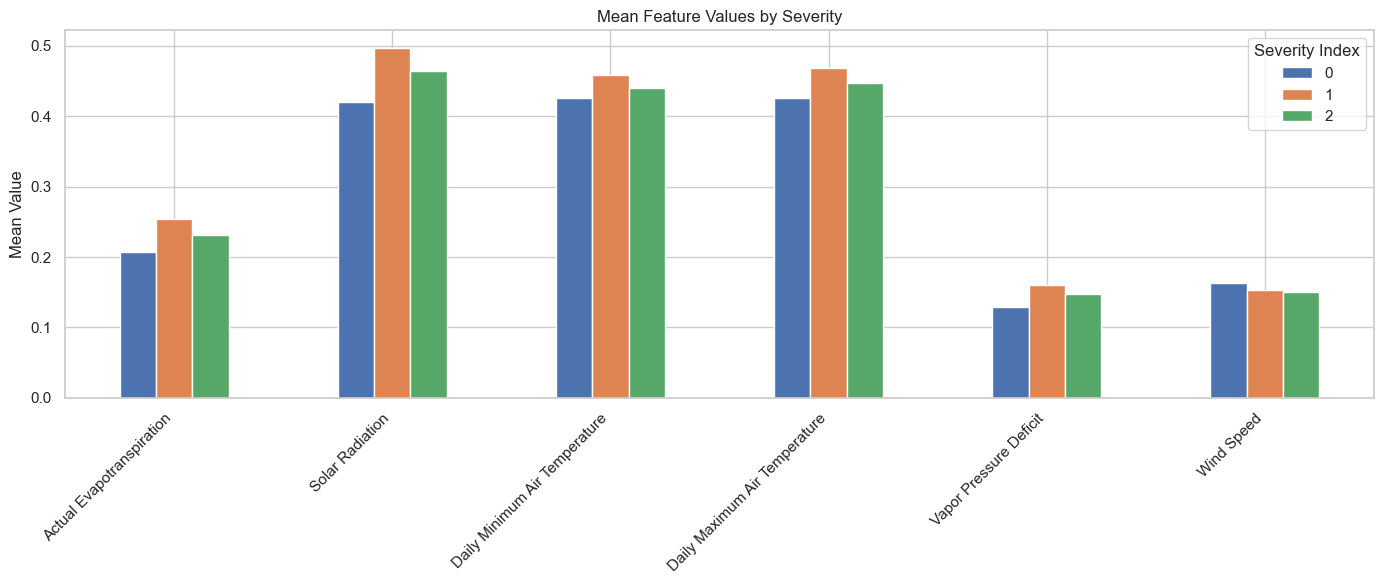

In [10]:
bar_group(X[water_demand])

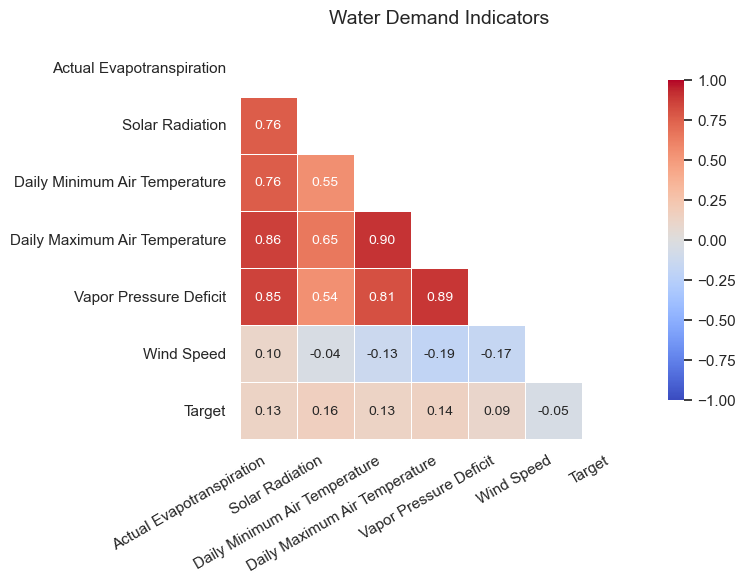

In [11]:
correlation_map(X[water_demand],'Water Demand Indicators')

---

## Water Supply Indicators

In [12]:
water_supply = [
    "Precipitation",
    "Maximum Relative Humidity",
    "Minimum Relative Humidity",
    "Specific Humidity",
    "100-hour Dead Fuel Moisture",
    "1000-hour Dead Fuel Moisture",
    'Target'
]

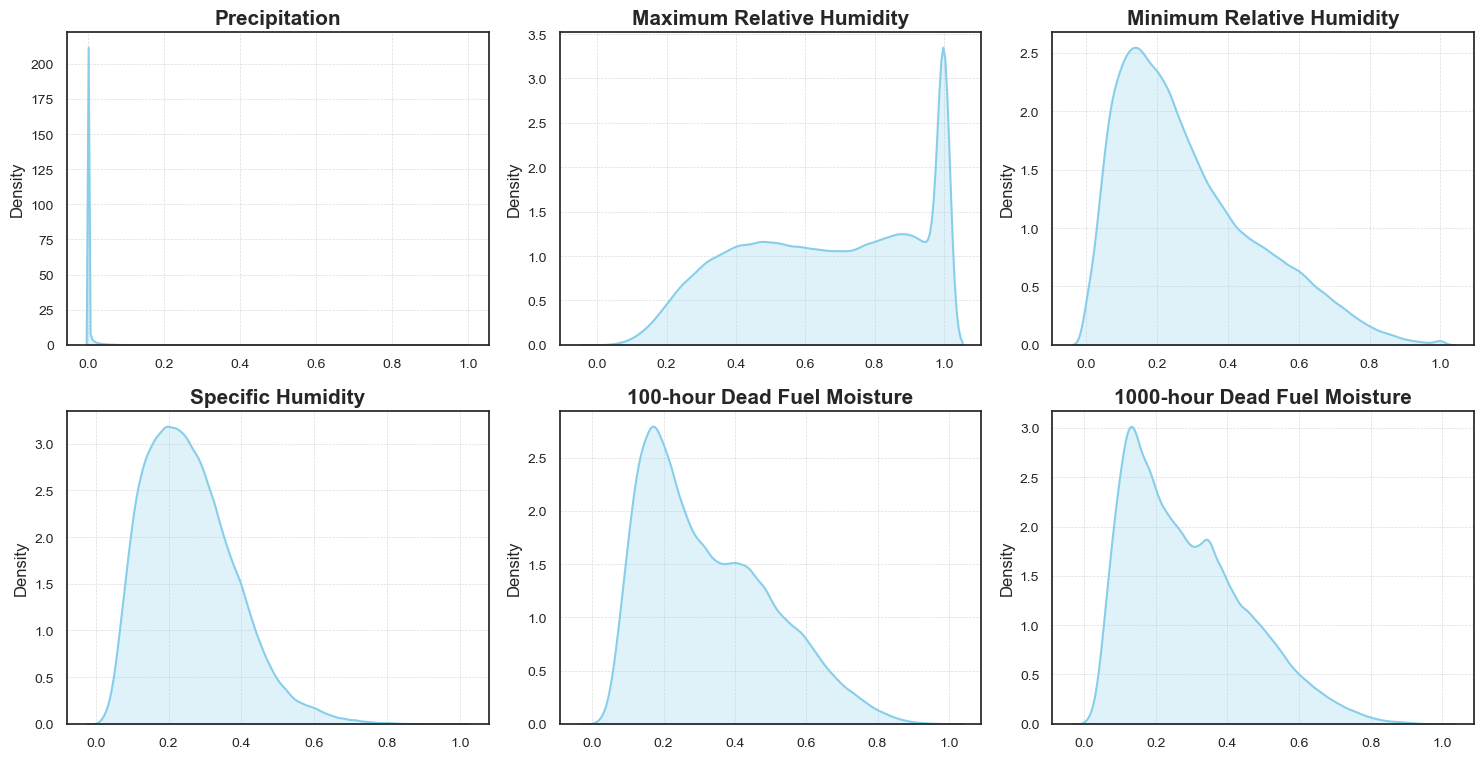

In [13]:
grid_kde(X[water_supply].drop(columns='Target'))

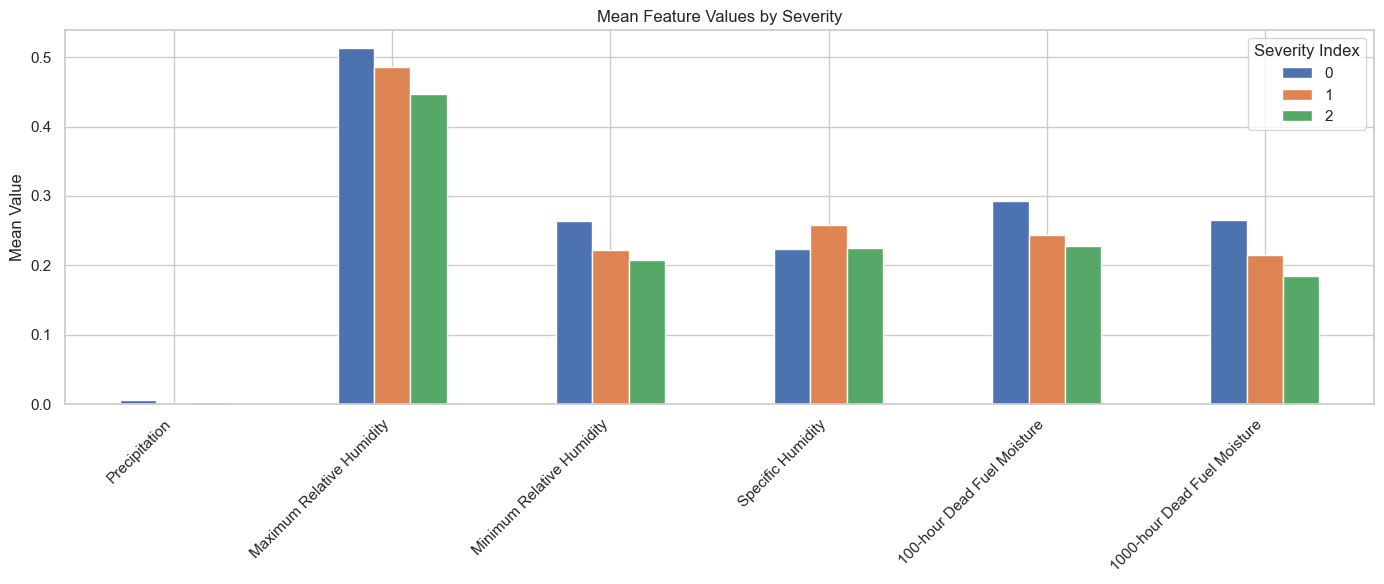

In [14]:
bar_group(X[water_supply])

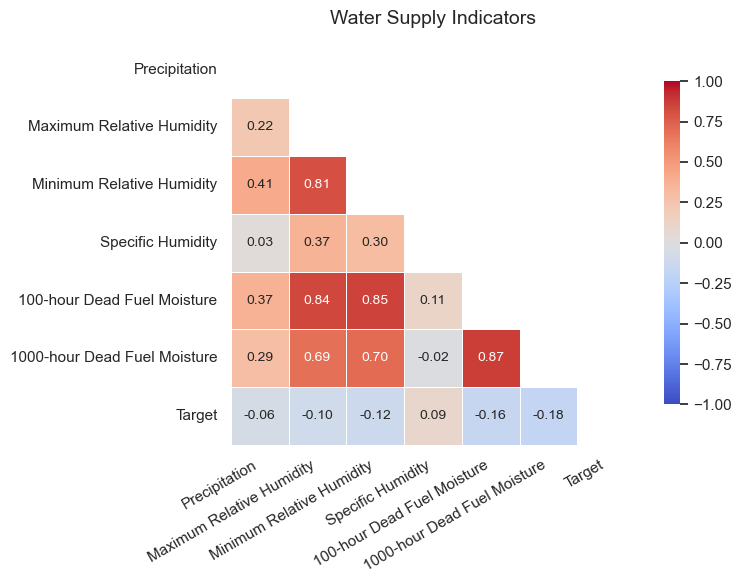

In [15]:
correlation_map(X[water_supply],'Water Supply Indicators')

---

## Water Supply Indexes

In [16]:
water_supply_indexes = ["Standardized Precipitation Index 30-Day",
    "Standardized Precipitation Index 180-Day",
    "Standardized Precipitation Evapotranspiration Index 30-Day",
    "Standardized Precipitation Evapotranspiration Index 90-Day",
    "Standardized Precipitation Evapotranspiration Index 180-Day",
    "Palmer Drought Severity Index",
                       'Target']

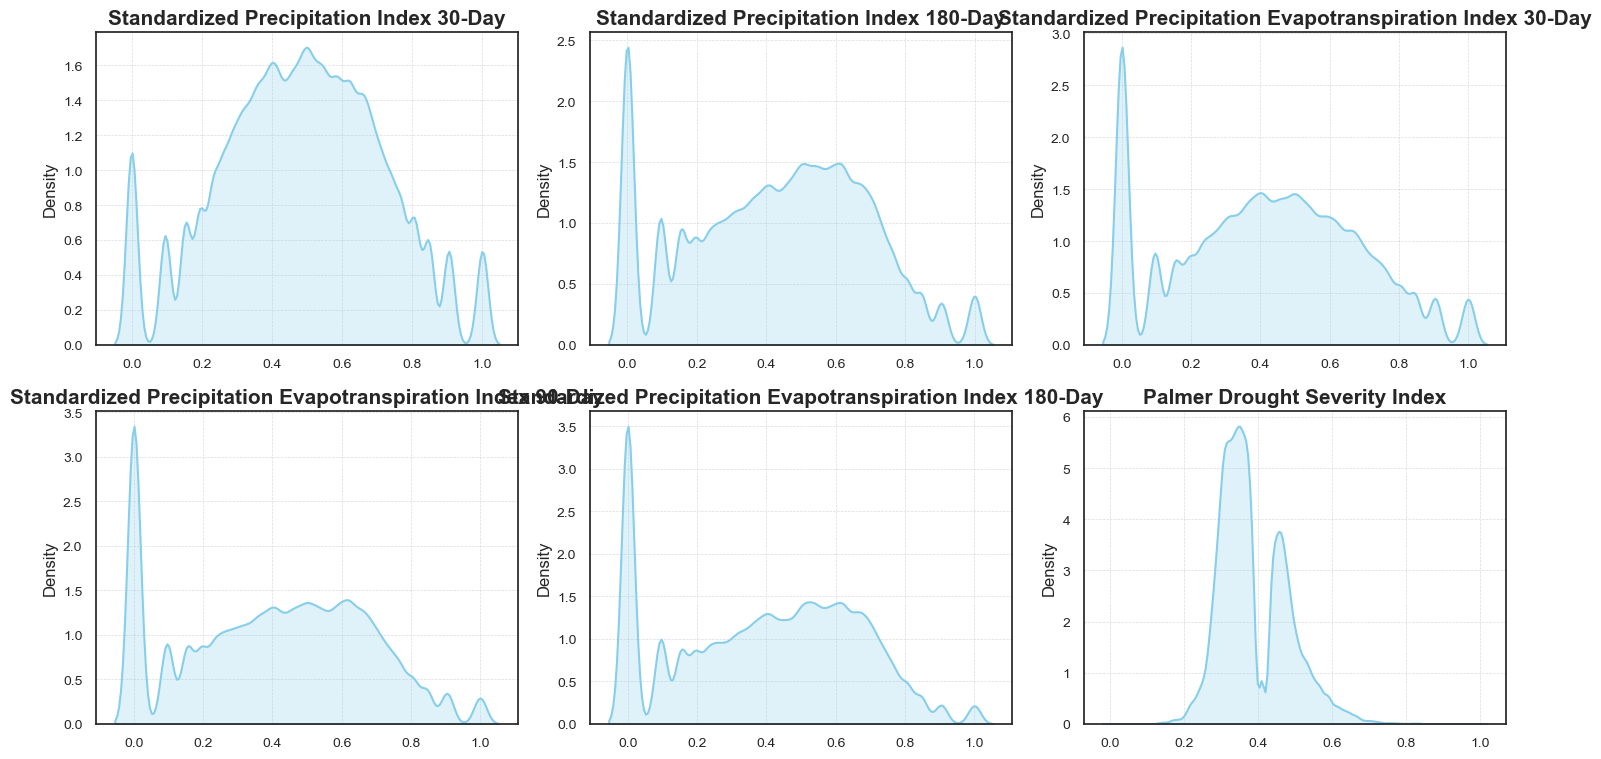

In [17]:
grid_kde(X[water_supply_indexes].drop(columns='Target'))

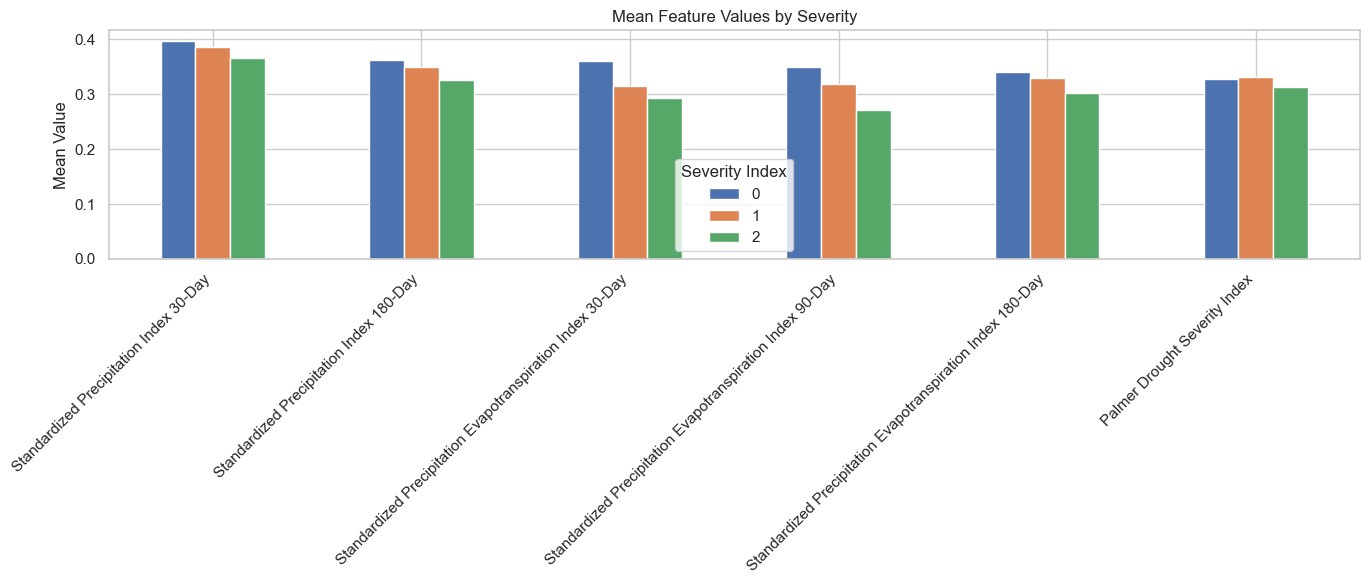

In [18]:
bar_group(X[water_supply_indexes])

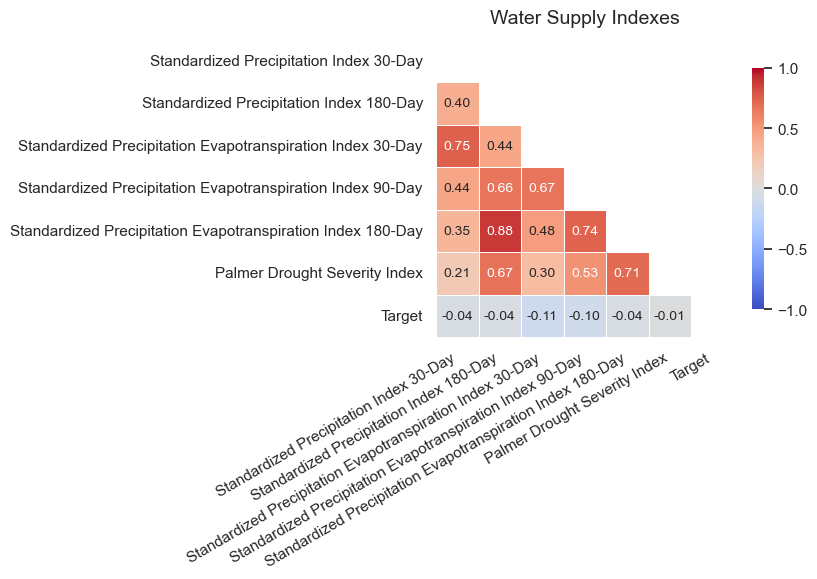

In [19]:
correlation_map(X[water_supply_indexes],'Water Supply Indexes')

## Fire Danger

In [20]:
fire_danger = [
    "Burning Index",
    "Energy Release Component",
    'Target']

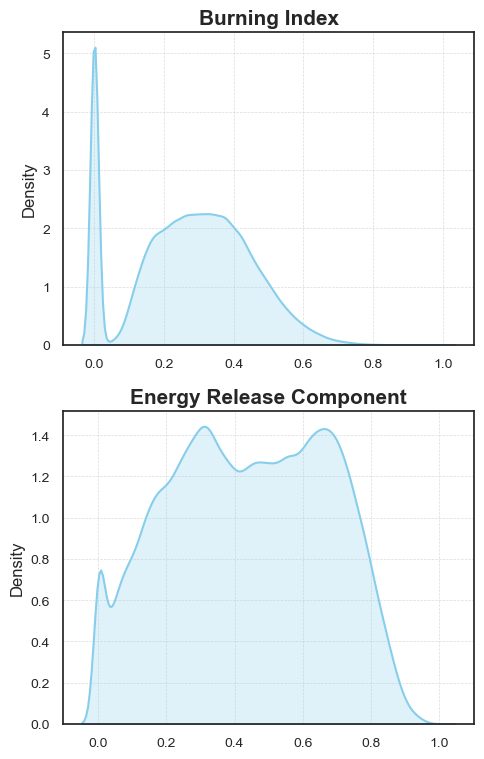

In [21]:
grid_kde(X[fire_danger].drop(columns='Target'))

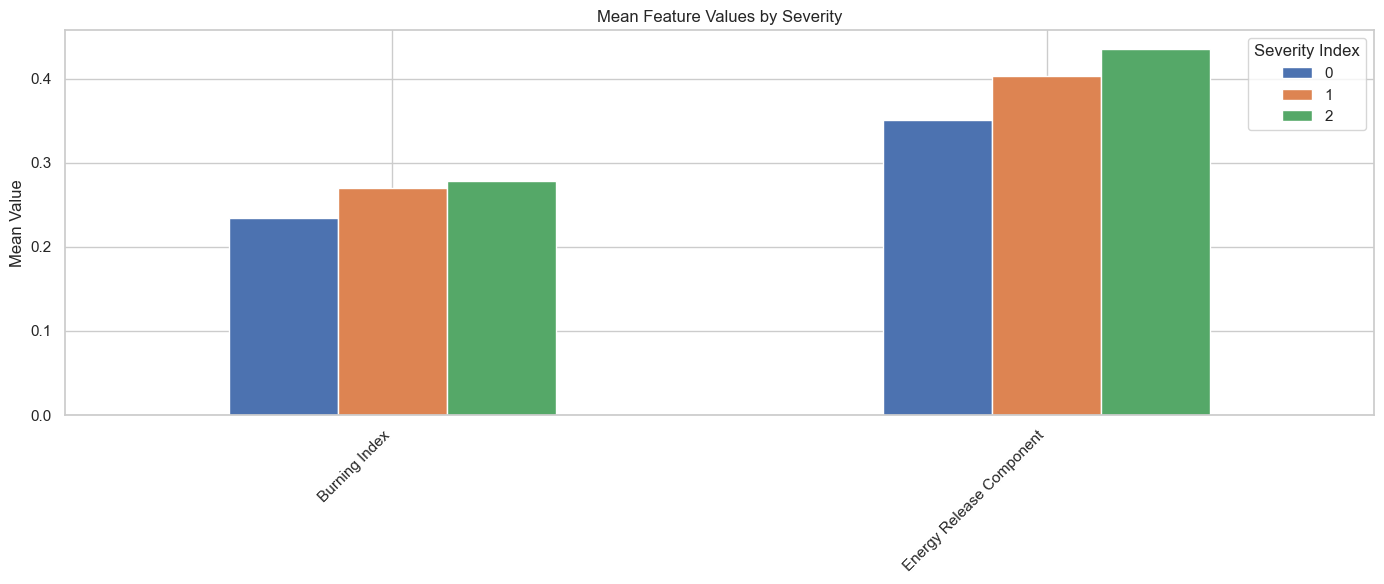

In [22]:
bar_group(X[fire_danger])

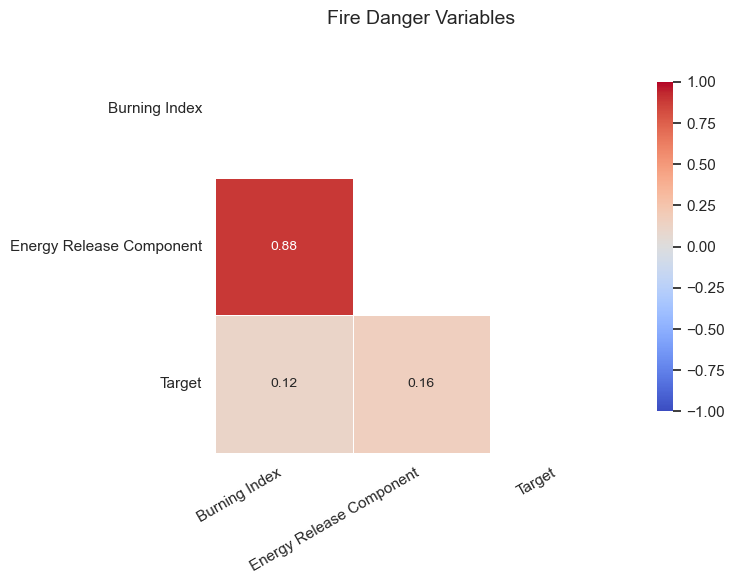

In [23]:
correlation_map(X[fire_danger],'Fire Danger Variables')

## Social Variables

In [24]:
Social = ['total_housing', 'total_population',
       'housing_density', 'population_density', 'median_income','Target']

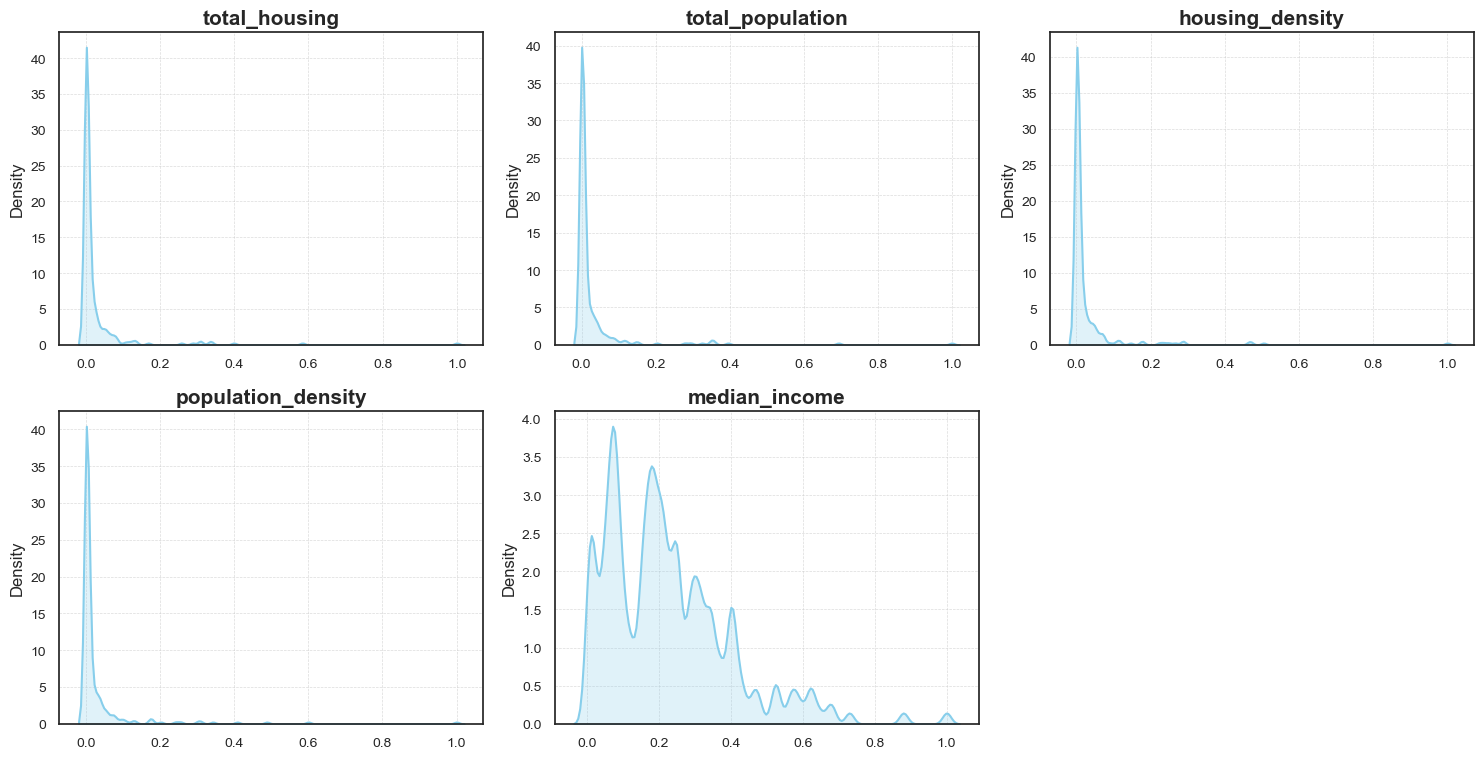

In [25]:
grid_kde(X[Social].drop(columns='Target'))

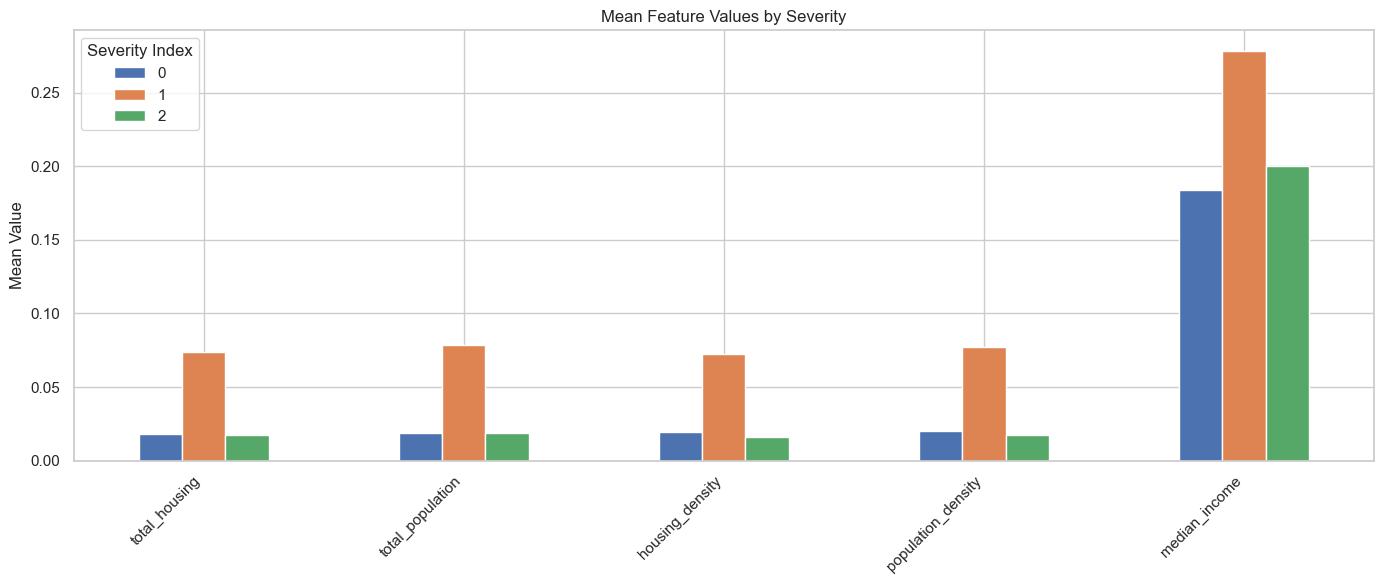

In [26]:
bar_group(X[Social])

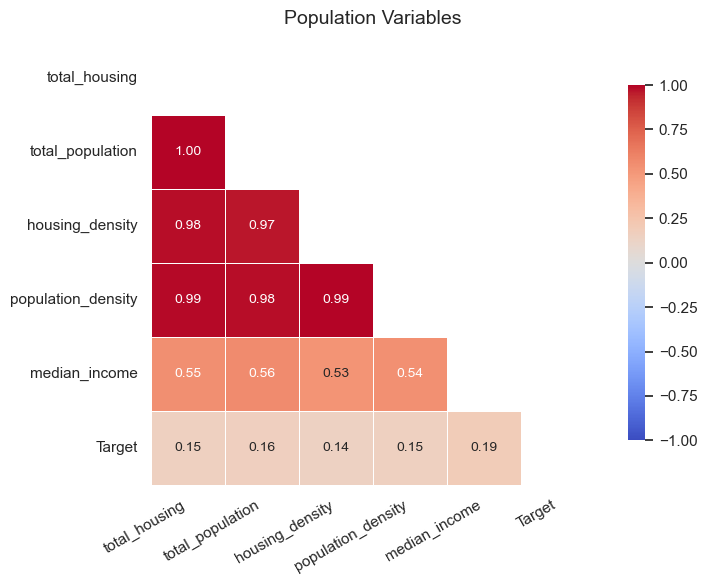

In [27]:
correlation_map(X[Social],'Population Variables')

## Temporal Variables

In [28]:
Temp = ['Year','2-Year Avg Fires','Santa_Ana_Score','Target']

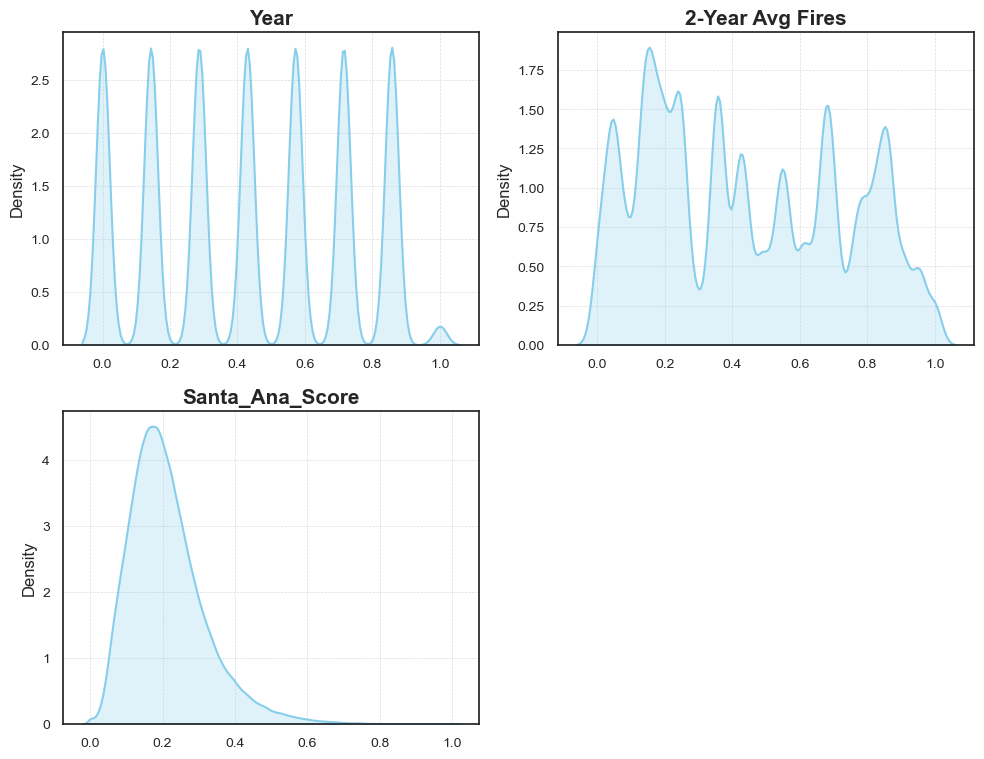

In [29]:
grid_kde(X[Temp].drop(columns='Target'))

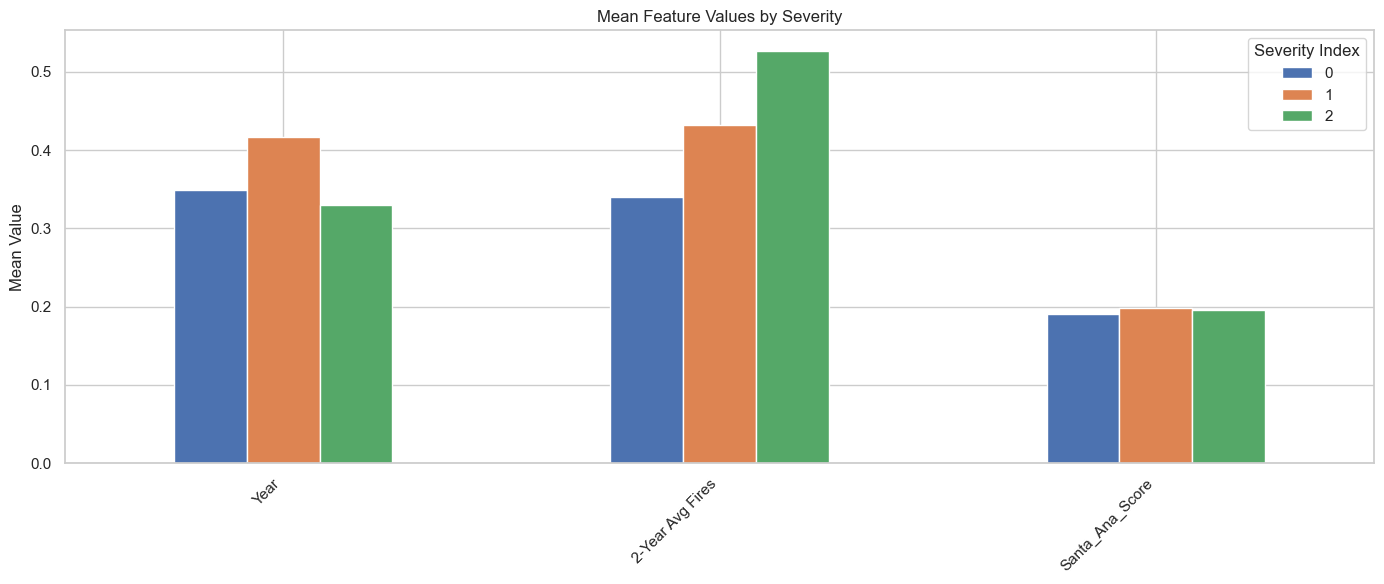

In [30]:
bar_group(X[Temp])

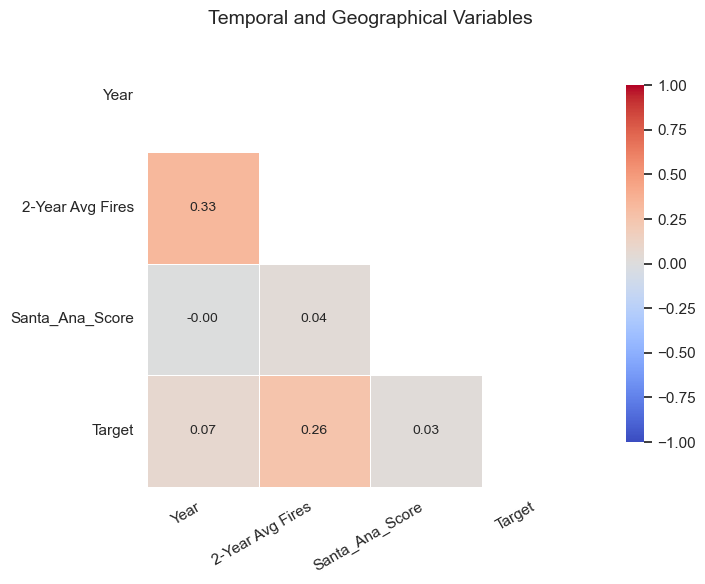

In [31]:
correlation_map(X[Temp],'Temporal and Geographical Variables')

## Elevation

In [32]:
Elevation = ['elevation_range', 'elevation_mean',
       'elevation_std', 'slope_max', 'slope_range', 'slope_mean', 'slope_std',
       'northness_mean', 'eastness_mean','Target']

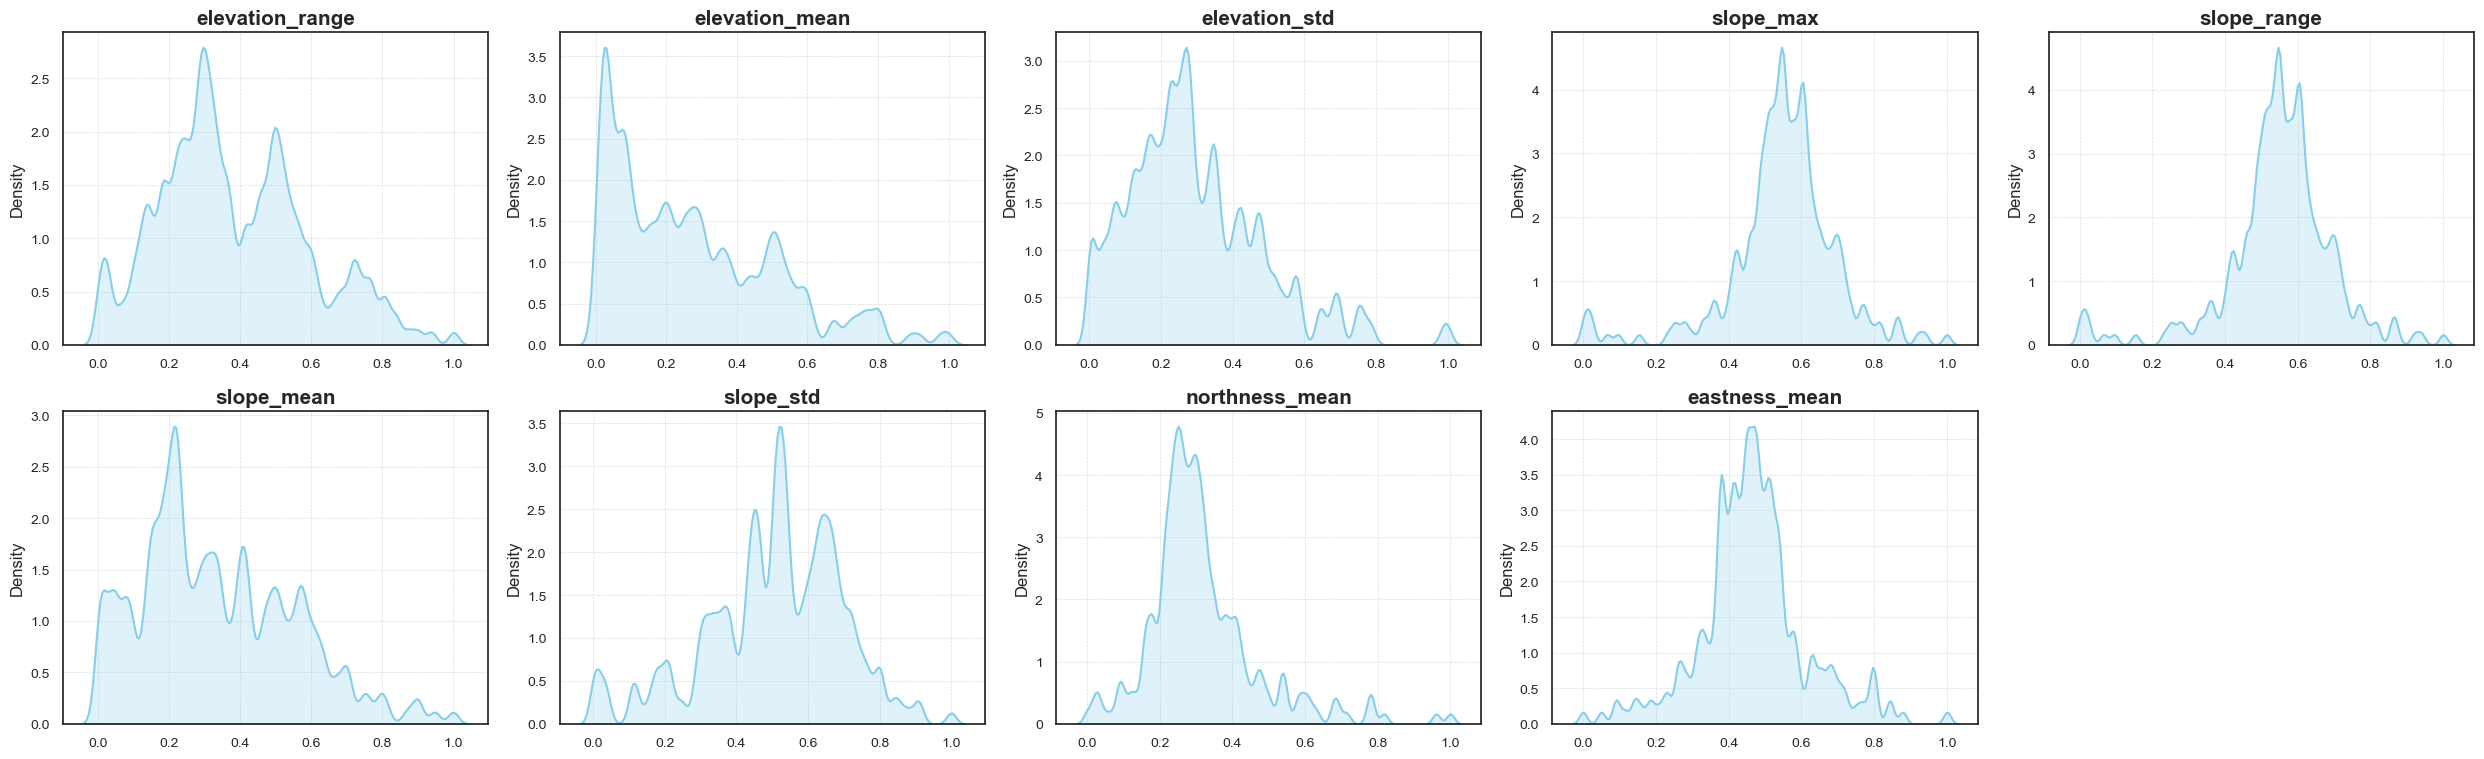

In [33]:
grid_kde(X[Elevation].drop(columns='Target'))

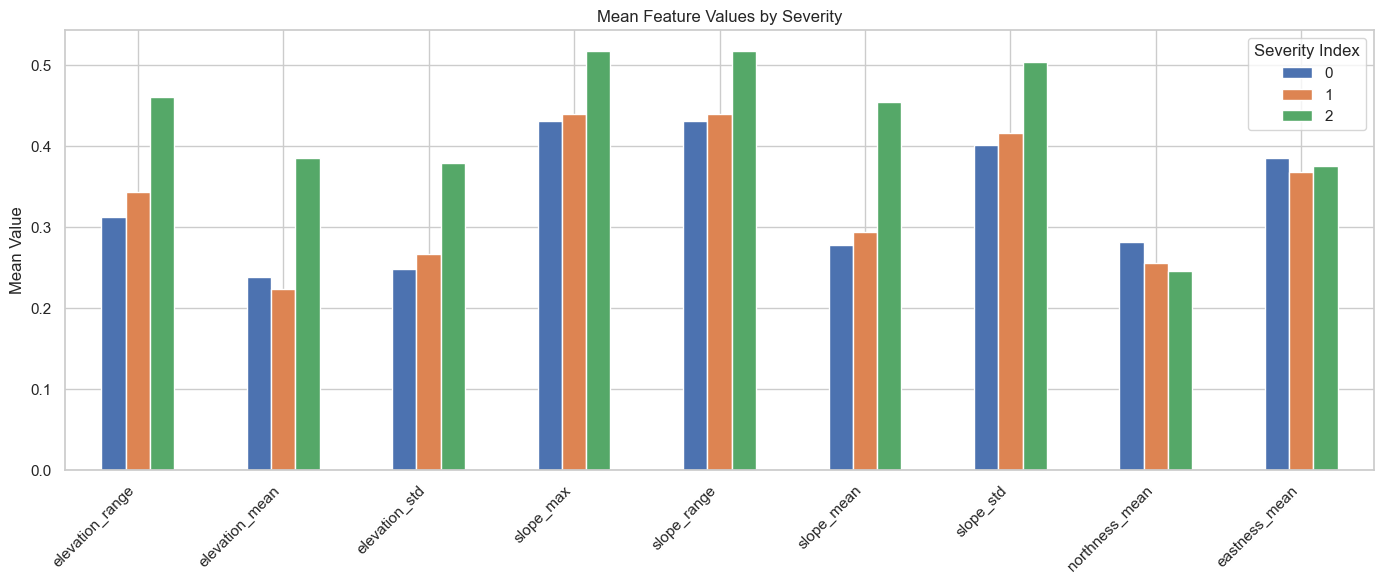

In [34]:
bar_group(X[Elevation])

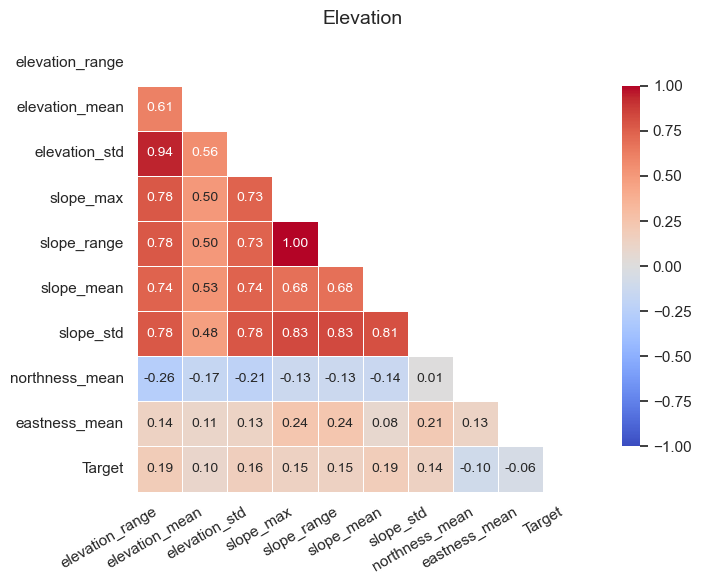

In [35]:
correlation_map(X[Elevation],'Elevation')

## WUI

In [36]:
WUI = ['influence_zone', 'interface_zone', 'intermix_zone','Target']

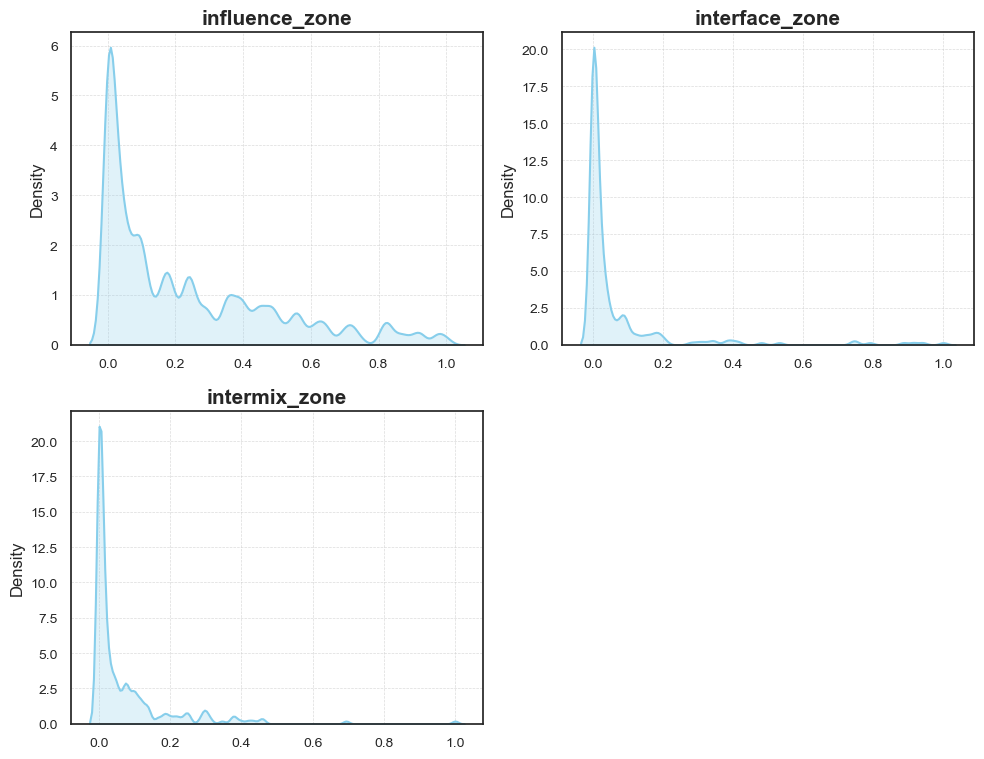

In [37]:
grid_kde(X[WUI].drop(columns='Target'))

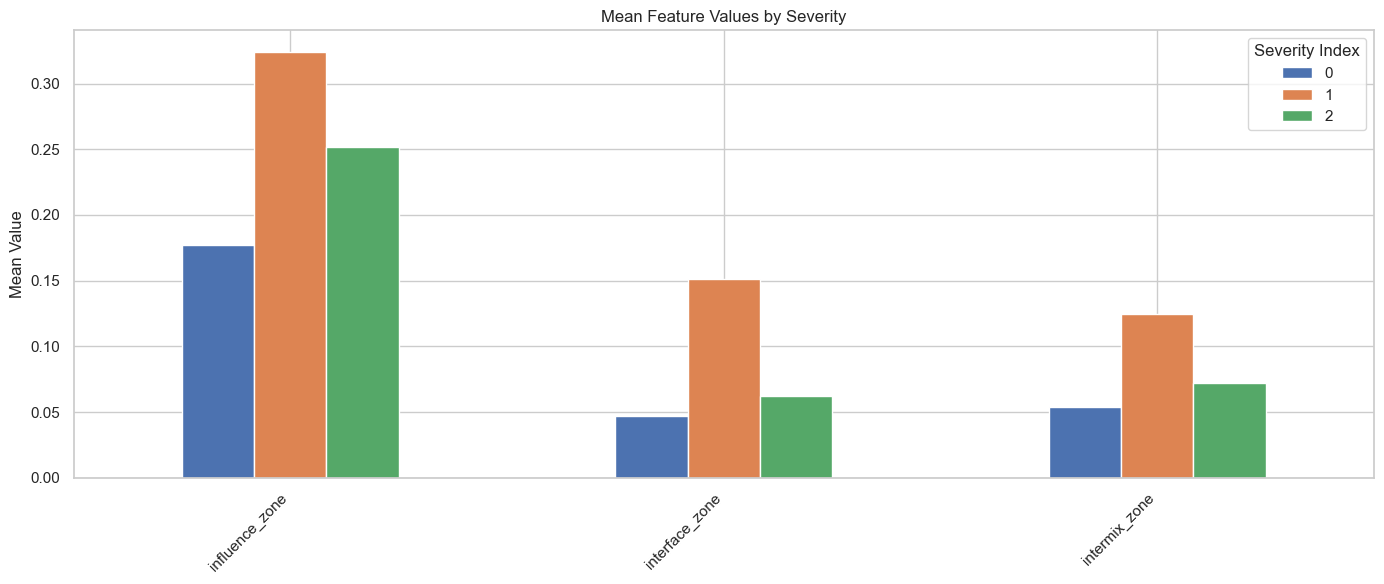

In [38]:
bar_group(X[WUI])

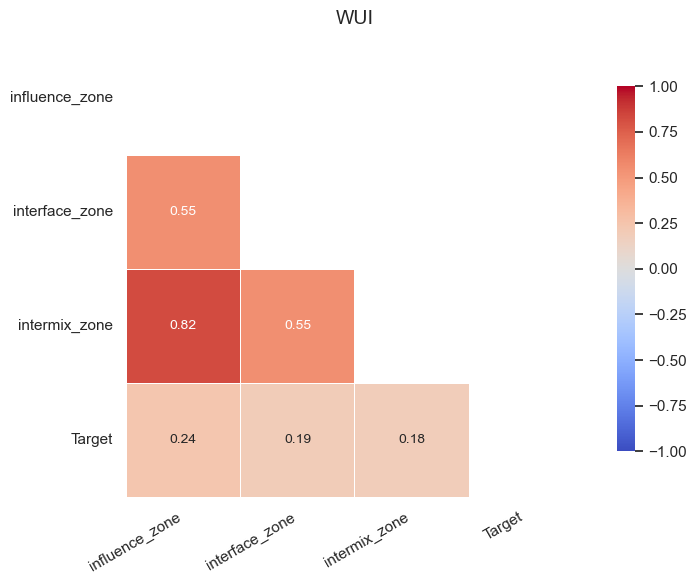

In [39]:
correlation_map(X[WUI],'WUI')

## Ecological

In [40]:
Eco = [ 'dominant_province_percent',
       'sum_province_area', 'sum_section_area',
       'dominant_section_percent','Target']

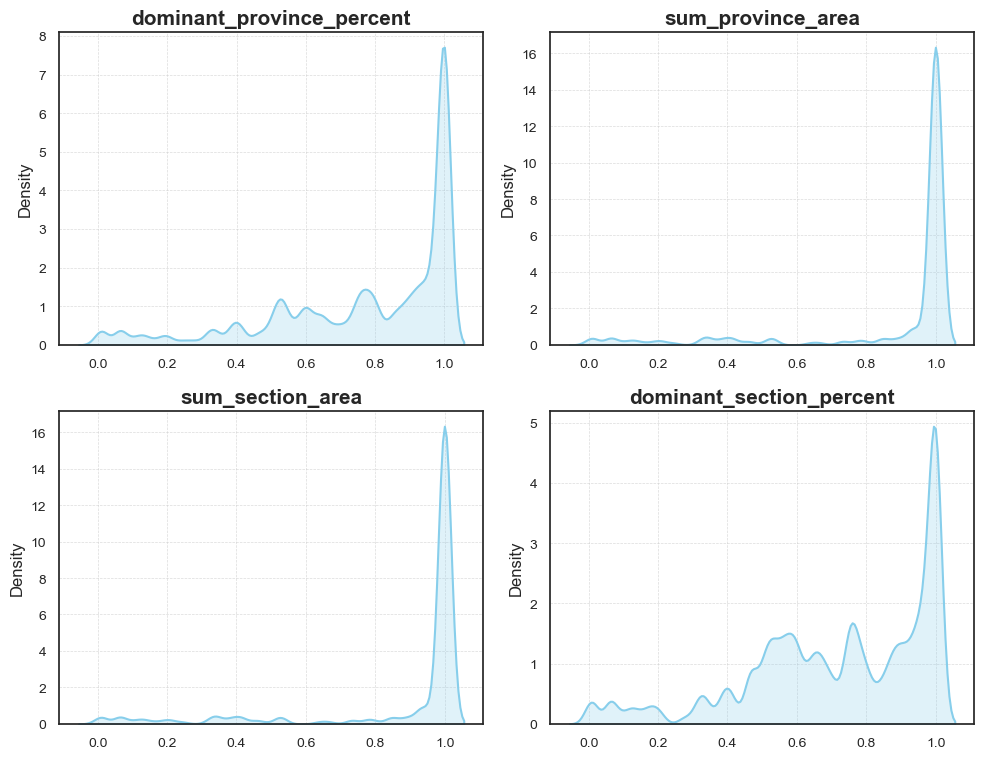

In [41]:
grid_kde(X[Eco].drop(columns='Target'))

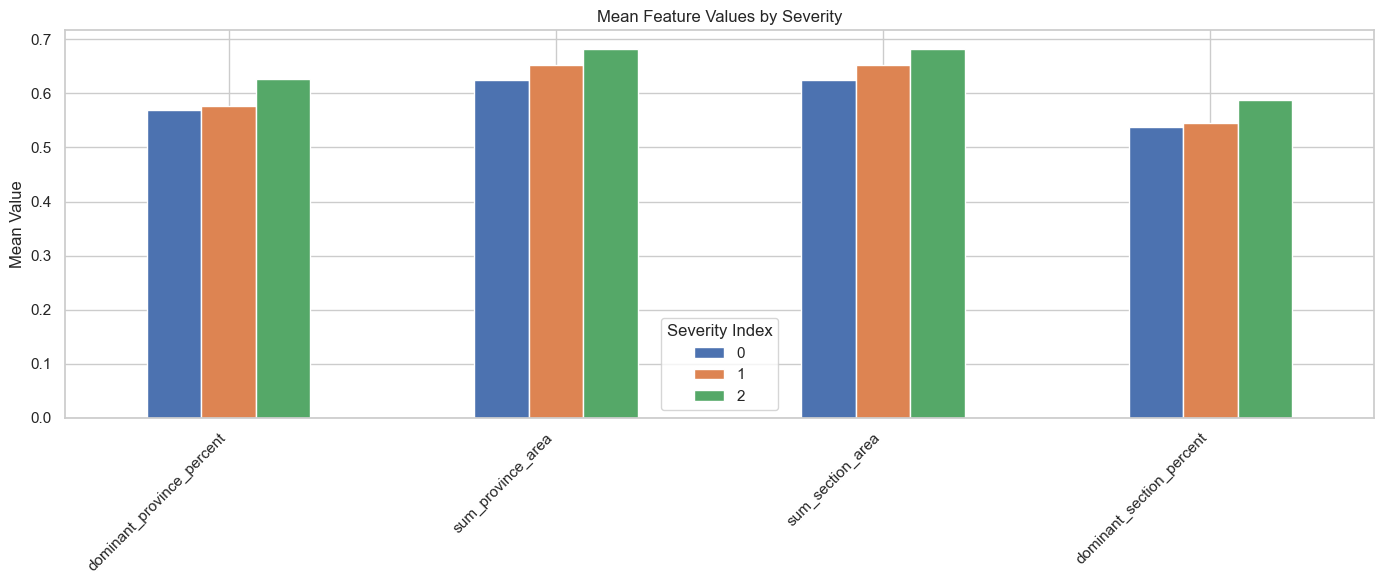

In [42]:
bar_group(X[Eco])

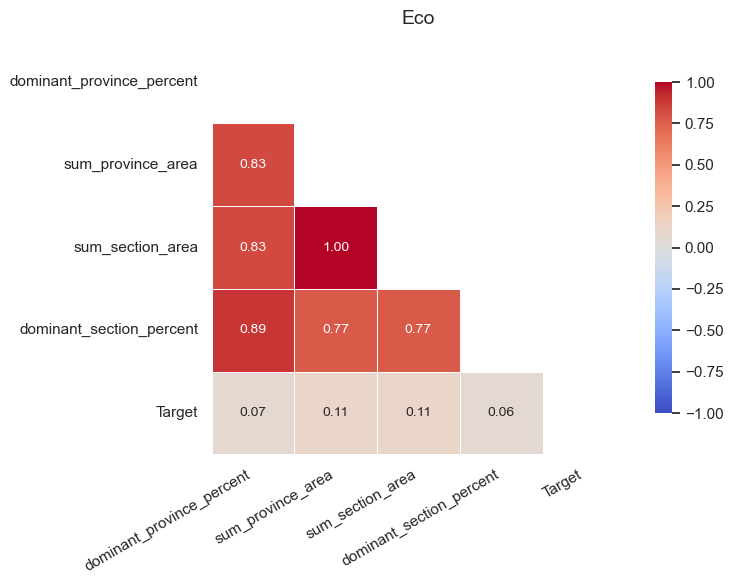

In [43]:
correlation_map(X[Eco],'Eco')

## Land Cover

In [44]:
Land = ['forest_percent','developed_percent', 'other_percent', 'shrub_grass_percent',
       'wetlands_percent','Target']

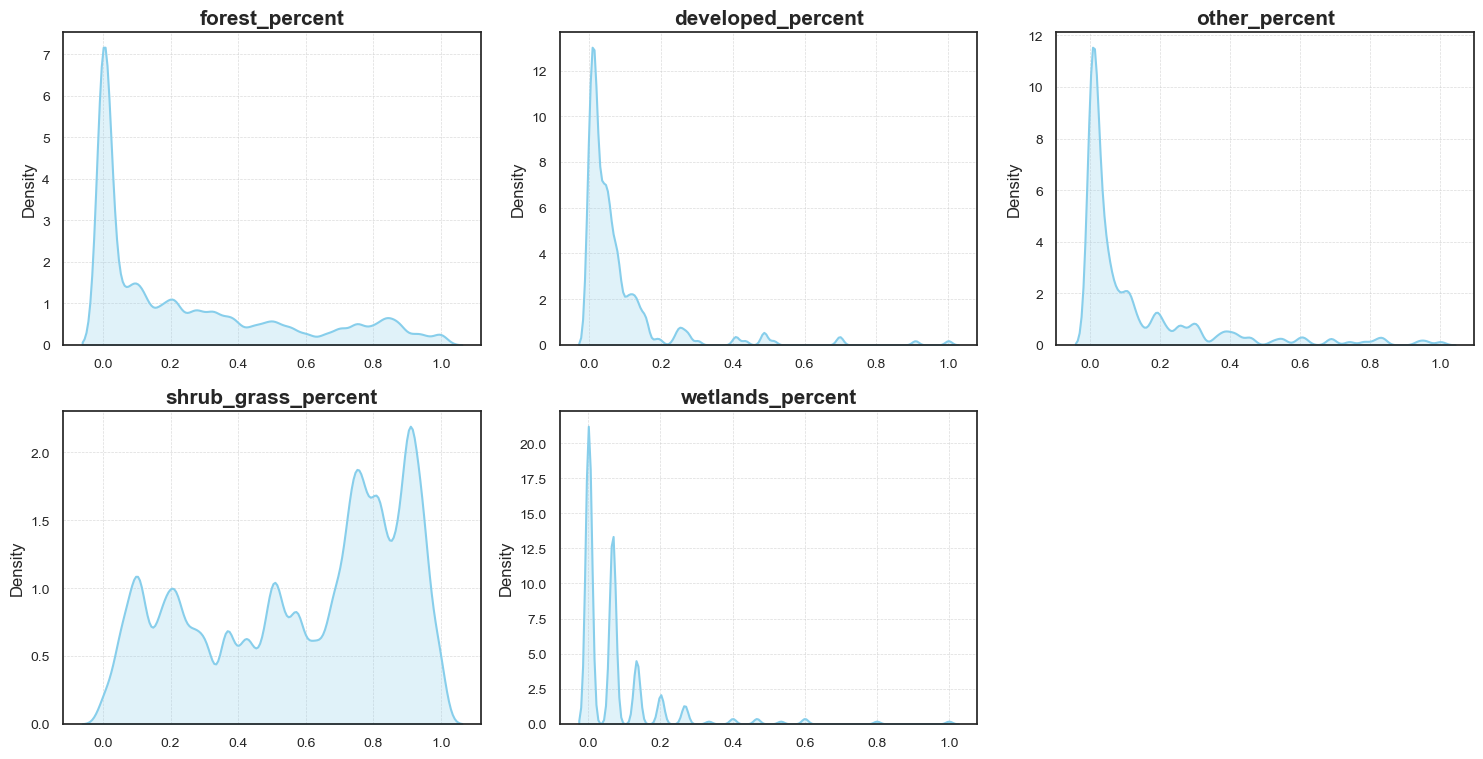

In [45]:
grid_kde(X[Land].drop(columns='Target'))

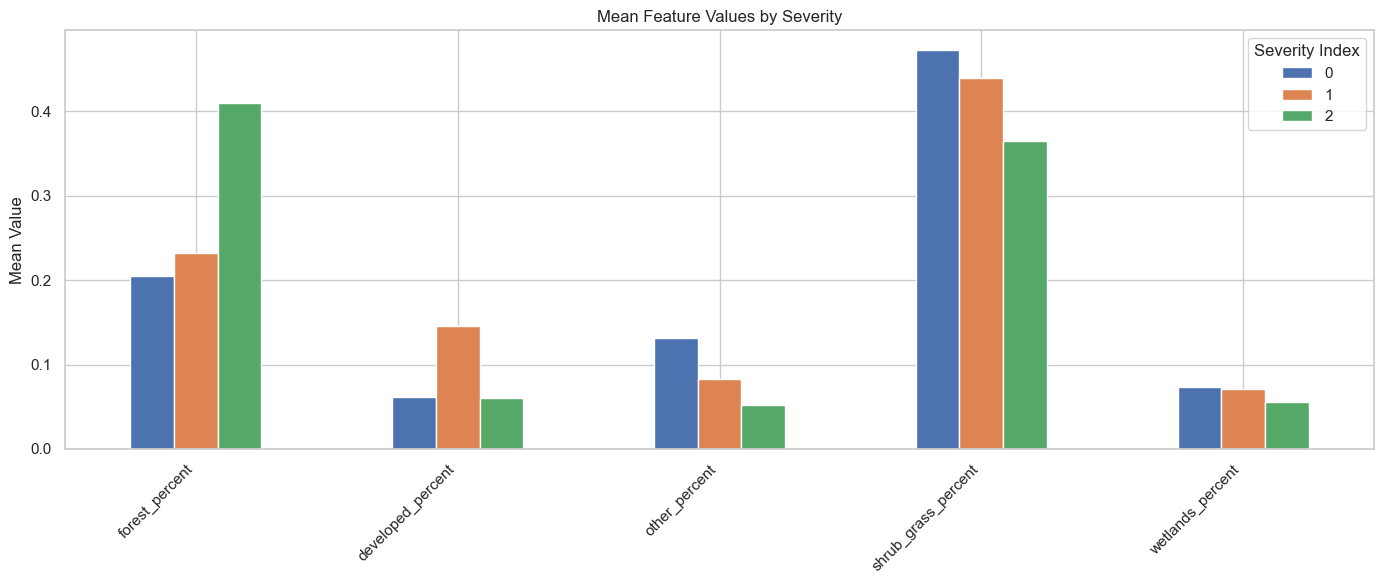

In [46]:
bar_group(X[Land])

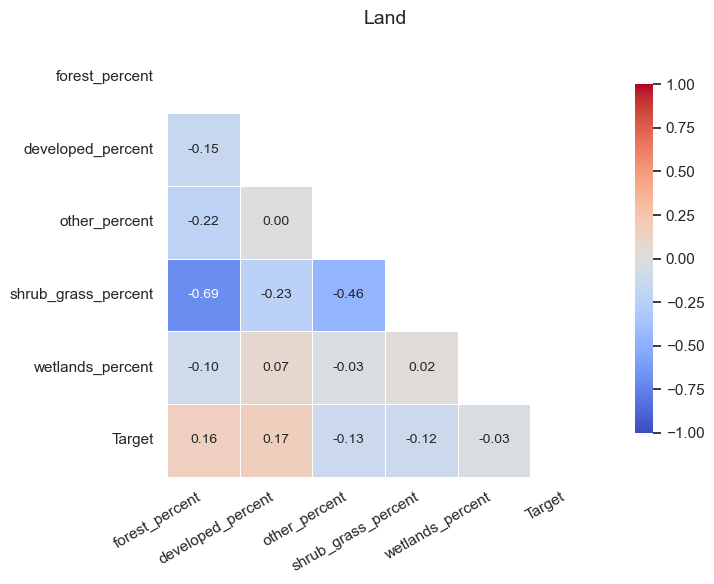

In [47]:
correlation_map(X[Land],'Land')

---

In [48]:
interaction_columns = ['Wind Speed_x_100-hour Dead Fuel Moisture',
 'Vapor Pressure Deficit_x_Solar Radiation',
 'Precipitation_x_1000-hour Dead Fuel Moisture',
 'northness_mean_x_Daily Maximum Air Temperature',
 'road_density_x_forest_percent',
 'power_line_density_x_total_housing',
 '2-Year Avg Fires_x_Precipitation 7 Day Avg',
 'Target']

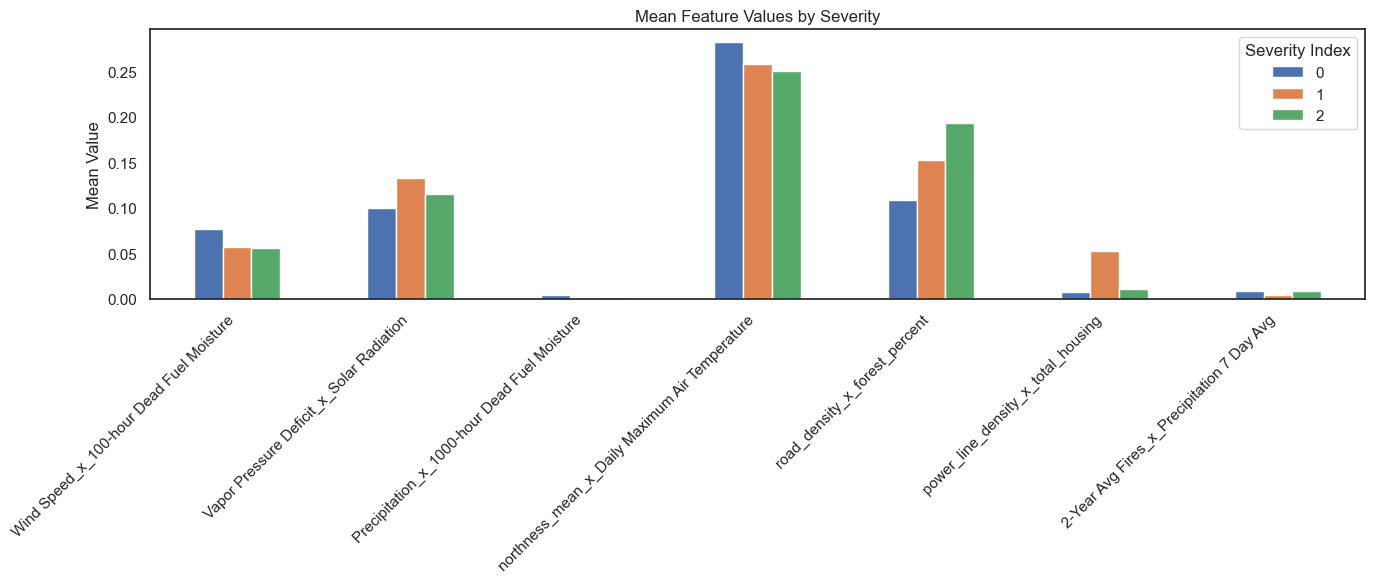

In [49]:
bar_group(X[interaction_columns])

In [50]:
mid = len(interaction_columns) // 2
first_half_interactions = interaction_columns[:mid]
second_half_interactions = interaction_columns[mid:] + ['Target']

In [51]:
second_half_interactions

['road_density_x_forest_percent',
 'power_line_density_x_total_housing',
 '2-Year Avg Fires_x_Precipitation 7 Day Avg',
 'Target',
 'Target']

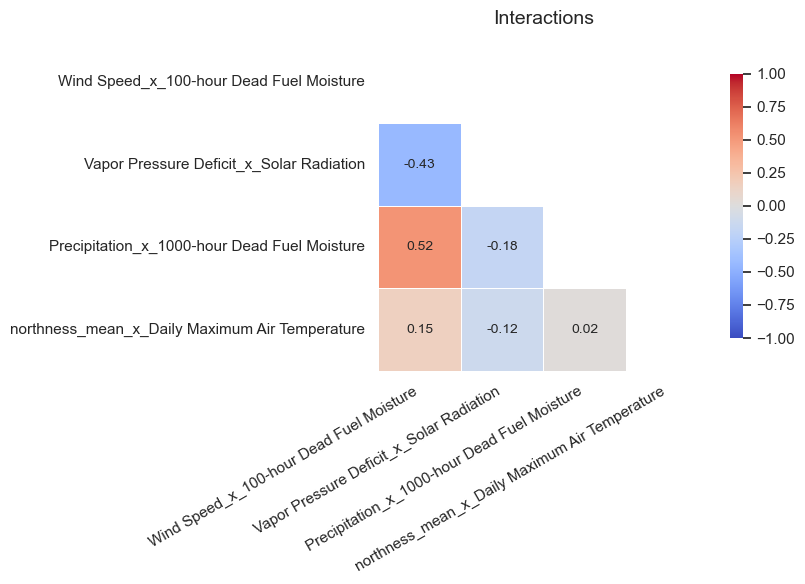

In [52]:
correlation_map(X[first_half_interactions],'Interactions')

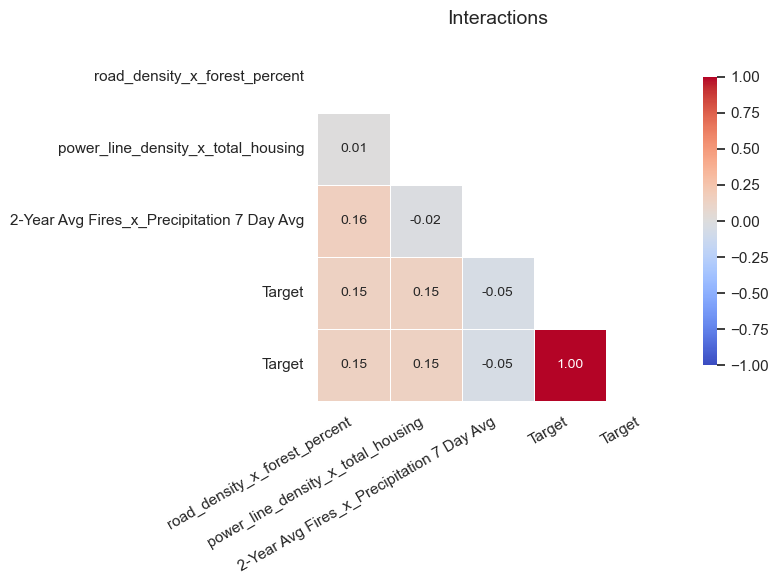

In [53]:
correlation_map(X[second_half_interactions],'Interactions')

## Wind Slope Interaction

In [54]:
wind_slope = ['Wind Speed_x_slope_mean',
 'Wind Speed_x_slope_max',
 'Wind Speed_x_northness_mean',
 'Wind Speed_x_eastness_mean',
 'Wind Speed_x_elevation_mean',
 'Wind Speed_x_elevation_range',
 'Wind Speed 7 Day Avg_x_slope_mean',
 'Wind Speed 7 Day Avg_x_slope_max',
 'Wind Speed 7 Day Avg_x_northness_mean',
 'Wind Speed 7 Day Avg_x_eastness_mean',
 'Wind Speed 7 Day Avg_x_elevation_mean',
 'Wind Speed 7 Day Avg_x_elevation_range',
 'Target']

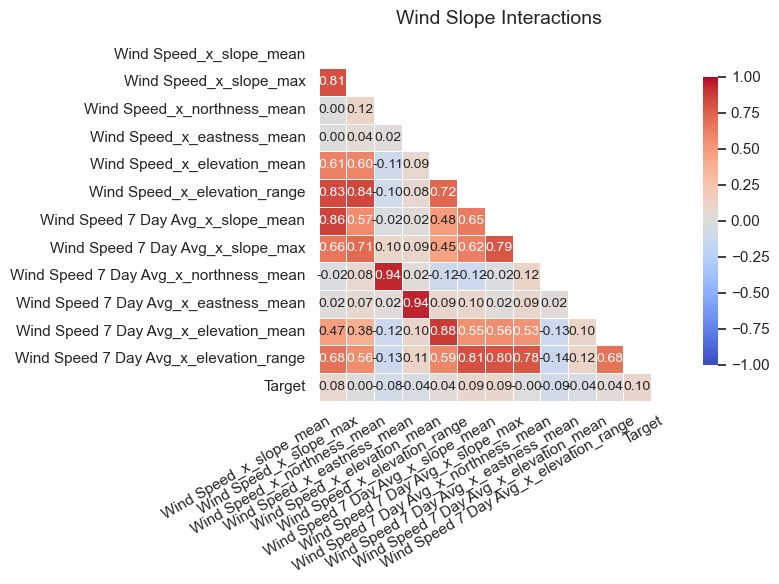

In [55]:
correlation_map(X[wind_slope],'Wind Slope Interactions')

In [56]:
X = X.drop(columns = 'Target')

In [57]:
variable_selection_output = pd.concat([X, detail_data], axis=1)

## 8. Export File

In [58]:
variable_selection_output.to_csv('../data/processed/variable_selection_output.csv', index=False)
print("All datasets saved successfully to ../data/processed/")

All datasets saved successfully to ../data/processed/
